In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.font_manager import fontManager, FontProperties

df_path = "/Users/royalmustaches/Documents/Programming/Dano/DANO_ITMO_2026/Datasets/DANO_ITMO.csv"
df = pd.read_csv(df_path)

PALETTE = ["#5e17eb", "#ff6b6b", "#00c49a"]
FONT_CANDIDATES = [
    "/Users/royalmustaches/Documents/Programming/Dano/DANO_ITMO_2026/HSE_FONTS_FOR_GRAPHS_copy/HSESlab-Regular.ttf",
    "/Users/royalmustaches/Documents/Programming/Dano/DANO_NES_2026/HSE_FONTS_FOR_GRAPHS/HSESlab-Regular.ttf",
    "/Users/royalmustaches/Documents/Programming/Dano/Practice/Organization/Fonts_for_projects/HSESlab-Regular.ttf",
]

FONT_NAME = "DejaVu Sans"
for font_path in FONT_CANDIDATES:
    if os.path.exists(font_path):
        fontManager.addfont(font_path)
        FONT_NAME = FontProperties(fname=font_path).get_name()
        break

sns.set_theme(style="whitegrid", font=FONT_NAME, context="notebook", palette=PALETTE)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["grid.linestyle"] = "--"

PRIMARY = "#5e17eb"
SECONDARY = "#ff6b6b"
ACCENT = "#00c49a"

In [2]:
import pandas as pd
import numpy as np

# df = pd.read_csv("Датасет_Дано (1).csv", encoding="utf-8-sig")

excluded_age_groups = ["58-62", "63+", "<18"]

df = (
    df
    # Удаляем NaN в age_group
    .dropna(subset=["age_group"])
    # Удаляем ненужные возрастные группы
    .loc[lambda x: ~x["age_group"].isin(excluded_age_groups)]
    .copy()
)

# Создаем порядок возрастных групп по нижней границе интервала
age_order = (
    df["age_group"]
    .drop_duplicates()
    .sort_values(key=lambda s: pd.to_numeric(s.str.extract(r"(\d+)")[0], errors="coerce"))
    .tolist()
)

# Создаем ранги: самая младшая оставшаяся группа = 0
age_rank_map = {group: rank for rank, group in enumerate(age_order)}

df["age_group_rank"] = df["age_group"].map(age_rank_map)

# Проверка
print(
    df[["age_group", "age_group_rank"]]
    .drop_duplicates()
    .sort_values("age_group_rank")
)

   age_group  age_group_rank
1      18-22               0
21     23-27               1
3      28-32               2
0      33-37               3
4      38-42               4
16     43-47               5
7      48-52               6
23     53-57               7


In [5]:
import pandas as pd
import statsmodels.api as sm

# 1. Загружаем данные
df = pd.read_csv("Datasets/DANO_ITMO.csv")

# 2. Оставляем только нужные переменные
cols = [
    "client_id",
    "revenue",
    "age_group",
    "cb_percent",
    "markup"
]

data = df[cols].copy()

# 3. Удаляем пропуски в переменных, которые участвуют в модели
data = data.dropna(subset=["client_id", "revenue", "age_group", "cb_percent", "markup"])

# 4. Приводим markup к числовому типу
data["markup"] = pd.to_numeric(data["markup"], errors="coerce")
data["cb_percent"] = pd.to_numeric(data["cb_percent"], errors="coerce")
data["revenue"] = pd.to_numeric(data["revenue"], errors="coerce")

data = data.dropna(subset=["revenue", "cb_percent", "markup"])

# 5. Создаем 4 категориальные переменные для уровней наценки
data["markup_0"] = (data["markup"] == 0).astype(int)
data["markup_1"] = (data["markup"] == 1).astype(int)
data["markup_5"] = (data["markup"] == 5).astype(int)
data["markup_9"] = (data["markup"] == 9).astype(int)

# Проверка: каждая строка должна попасть ровно в одну группу наценки
print(data[["markup_0", "markup_1", "markup_5", "markup_9"]].sum(axis=1).value_counts())

# 6. Кодируем возрастные группы как категориальные переменные
# drop_first=True, чтобы не создавать лишнюю мультиколлинеарность по возрасту
age_dummies = pd.get_dummies(
    data["age_group"],
    prefix="age",
    drop_first=True,
    dtype=int
)

# 7. Собираем матрицу признаков
# ВАЖНО: intercept не добавляем, чтобы можно было оставить все 4 dummy-переменные наценки
X = pd.concat(
    [
        data[["cb_percent", "markup_0", "markup_1", "markup_5", "markup_9"]],
        age_dummies
    ],
    axis=1
)

y = data["revenue"]

# 8. Строим линейную регрессию
# cov_type='cluster' учитывает, что заказы одного клиента не полностью независимы
model = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": data["client_id"]}
)

# 9. Выводим результаты
print(model.summary())

1    102342
Name: count, dtype: int64
                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                       nan
Date:                Sat, 25 Apr 2026   Prob (F-statistic):                nan
Time:                        13:24:46   Log-Likelihood:            -5.9865e+05
No. Observations:              102342   AIC:                         1.197e+06
Df Residuals:                  102327   BIC:                         1.197e+06
Df Model:                          14                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
cb_percent    

In [7]:
import pandas as pd
import statsmodels.api as sm

# 1. Загружаем данные
df = pd.read_csv("Datasets/DANO_ITMO.csv")

# 2. Оставляем нужные переменные
cols = [
    "client_id",
    "revenue",
    "age_group",
    "cb_percent",
    "markup"
]

data = df[cols].copy()

# 3. Приводим числовые переменные к корректному типу
data["revenue"] = pd.to_numeric(data["revenue"], errors="coerce")
data["cb_percent"] = pd.to_numeric(data["cb_percent"], errors="coerce")
data["markup"] = pd.to_numeric(data["markup"], errors="coerce")

# 4. Создаем ранжированную возрастную переменную
age_rank_map = {
    "<18": 0,
    "18-22": 1,
    "23-27": 2,
    "28-32": 3,
    "33-37": 4,
    "38-42": 5,
    "43-47": 6,
    "48-52": 7,
    "53-57": 8,
    "58-62": 9,
    "63+": 10
}

data["age_group_rank"] = data["age_group"].map(age_rank_map)

# 5. Удаляем пропуски в переменных модели
data = data.dropna(
    subset=[
        "client_id",
        "revenue",
        "cb_percent",
        "markup",
        "age_group_rank"
    ]
)

# 6. Создаем 4 dummy-переменные наценки
data["markup_0"] = (data["markup"] == 0).astype(int)
data["markup_1"] = (data["markup"] == 1).astype(int)
data["markup_5"] = (data["markup"] == 5).astype(int)
data["markup_9"] = (data["markup"] == 9).astype(int)

# Проверка: каждая строка должна принадлежать ровно одной группе наценки
print(
    data[["markup_0", "markup_1", "markup_5", "markup_9"]]
    .sum(axis=1)
    .value_counts()
)

# 7. Собираем X и y
# markup_0 НЕ включаем в X, потому что это базовая категория при наличии intercept
X = data[
    [
        "age_group_rank",
        "cb_percent",
        "markup_1",
        "markup_5",
        "markup_9"
    ]
]

y = data["revenue"]

# 8. Добавляем intercept
X = sm.add_constant(X)

# 9. Строим OLS-модель
# Cluster-robust SE нужны, потому что у одного client_id может быть несколько заказов
model = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": data["client_id"]}
)

# 10. Выводим результат
print(model.summary())

1    102342
Name: count, dtype: int64
                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     947.8
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:26:43   Log-Likelihood:            -5.9927e+05
No. Observations:              102342   AIC:                         1.199e+06
Df Residuals:                  102336   BIC:                         1.199e+06
Df Model:                           5                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const 

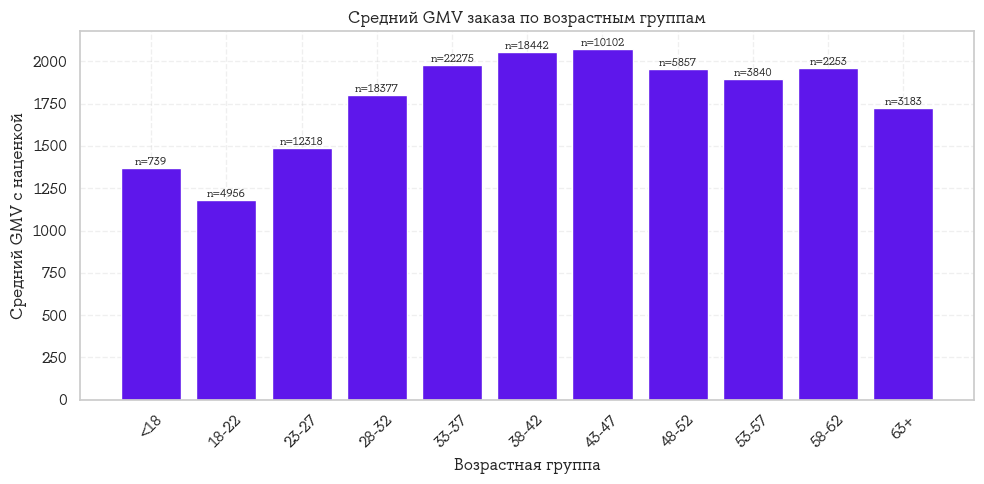

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/royalmustaches/Documents/Programming/Dano/DANO_ITMO_2026/Datasets/DANO_ITMO.csv")

gmv_col = "gmv_with_markup"

plot_df = df.dropna(subset=["age_group", gmv_col]).copy()

age_order = [
    "<18", "18-22", "23-27", "28-32", "33-37", "38-42",
    "43-47", "48-52", "53-57", "58-62", "63+"
]

summary = (
    plot_df
    .groupby("age_group", observed=True)
    .agg(
        mean_gmv=(gmv_col, "mean"),
        n_orders=(gmv_col, "size")
    )
    .reindex(age_order)
    .dropna()
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.bar(summary["age_group"], summary["mean_gmv"])

plt.title("Средний GMV заказа по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Средний GMV с наценкой")
plt.xticks(rotation=45)

for i, row in summary.iterrows():
    plt.text(
        i,
        row["mean_gmv"],
        f"n={int(row['n_orders'])}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

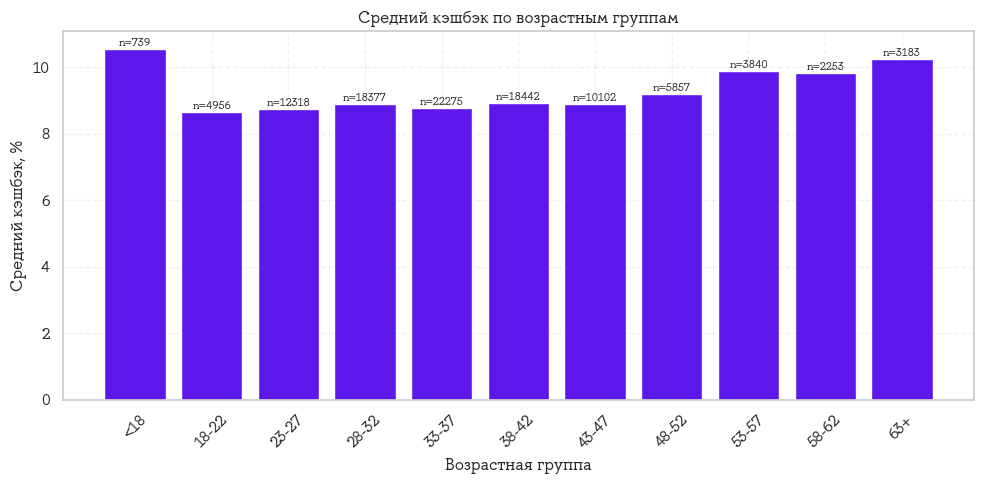

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/royalmustaches/Documents/Programming/Dano/DANO_ITMO_2026/Datasets/DANO_ITMO.csv")

cb_col = "cb_percent"

plot_df = df.dropna(subset=["age_group", cb_col]).copy()

age_order = [
    "<18", "18-22", "23-27", "28-32", "33-37", "38-42",
    "43-47", "48-52", "53-57", "58-62", "63+"
]

summary_cb = (
    plot_df
    .groupby("age_group", observed=True)
    .agg(
        mean_cb=(cb_col, "mean"),
        n_orders=(cb_col, "size")
    )
    .reindex(age_order)
    .dropna()
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.bar(summary_cb["age_group"], summary_cb["mean_cb"])

plt.title("Средний кэшбэк по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Средний кэшбэк, %")
plt.xticks(rotation=45)

for i, row in summary_cb.iterrows():
    plt.text(
        i,
        row["mean_cb"],
        f"n={int(row['n_orders'])}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

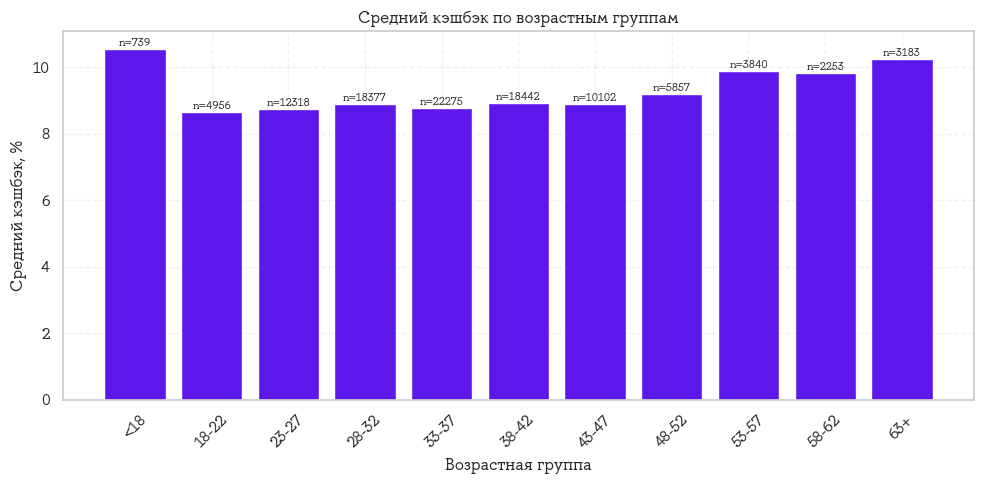

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/royalmustaches/Documents/Programming/Dano/DANO_ITMO_2026/Datasets/DANO_ITMO.csv")

cb_col = "cb_percent"

plot_df = df.dropna(subset=["age_group", cb_col]).copy()

age_order = [
    "<18", "18-22", "23-27", "28-32", "33-37", "38-42",
    "43-47", "48-52", "53-57", "58-62", "63+"
]

summary_cb = (
    plot_df
    .groupby("age_group", observed=True)
    .agg(
        mean_cb=(cb_col, "mean"),
        n_orders=(cb_col, "size")
    )
    .reindex(age_order)
    .dropna()
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.bar(summary_cb["age_group"], summary_cb["mean_cb"])

plt.title("Средний кэшбэк по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Средний кэшбэк, %")
plt.xticks(rotation=45)

for i, row in summary_cb.iterrows():
    plt.text(
        i,
        row["mean_cb"],
        f"n={int(row['n_orders'])}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

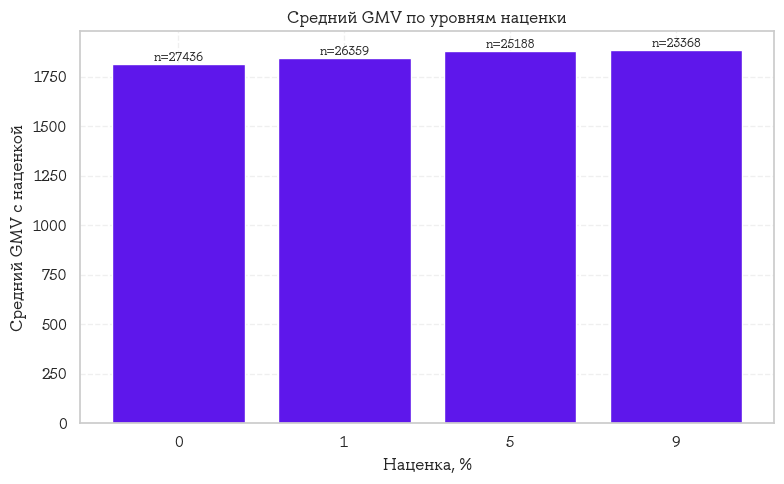

,markup,mean_value,n_orders
0,0,1816.164547,27436
1,1,1845.438416,26359
2,5,1879.866361,25188
3,9,1886.491590,23368


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv("/Users/royalmustaches/Documents/Programming/Dano/DANO_ITMO_2026/Datasets/DANO_ITMO.csv")

# Что усредняем
target_col = "gmv_with_markup"

# По какой переменной группируем
group_col = "markup"

# Удаляем пропуски
plot_df = df.dropna(subset=[group_col, target_col]).copy()

# Считаем средние значения по уровням наценки
summary = (
    plot_df
    .groupby(group_col, as_index=False)
    .agg(
        mean_value=(target_col, "mean"),
        n_orders=(target_col, "size")
    )
    .sort_values(group_col)
)

# Строим столбчатый график
plt.figure(figsize=(8, 5))
plt.bar(summary[group_col].astype(str), summary["mean_value"])

plt.title("Средний GMV по уровням наценки")
plt.xlabel("Наценка, %")
plt.ylabel("Средний GMV с наценкой")

# Подписи количества заказов
for i, row in summary.iterrows():
    plt.text(
        x=i,
        y=row["mean_value"],
        s=f"n={int(row['n_orders'])}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# Таблица со значениями
summary

In [13]:
import pandas as pd
import numpy as np

import statsmodels.formula.api as smf

# =========================
# 1. Подготовка данных
# =========================

df_model = df.copy()

df_model.columns = (
    df_model.columns
    .str.replace('\ufeff', '', regex=False)
    .str.strip()
)

# Оставляем наблюдения с корректным GMV и наценкой
df_model = df_model.dropna(
    subset=[
        'gmv_with_markup',
        'markup'
    ]
).copy()

df_model = df_model[df_model['gmv_with_markup'] > 0].copy()
df_model = df_model[df_model['markup'].isin([0, 1, 5, 9])].copy()

# Наценка как категориальная переменная
df_model['markup'] = df_model['markup'].astype(int)

# =========================
# 2. Линейная регрессия
# =========================
# Базовая категория: markup = 0
# Коэффициенты при markup = 1, 5, 9 показывают,
# насколько средний gmv_with_markup отличается от группы без наценки

formula = """
gmv_with_markup ~ C(markup, Treatment(reference=0))
"""

# Если есть client_id, кластеризуем ошибки по клиенту
if 'client_id' in df_model.columns:
    model = smf.ols(
        formula=formula,
        data=df_model
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_model['client_id']}
    )
else:
    model = smf.ols(
        formula=formula,
        data=df_model
    ).fit(cov_type='HC3')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        gmv_with_markup   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     4.786
Date:                Sat, 25 Apr 2026   Prob (F-statistic):            0.00246
Time:                        13:57:28   Log-Likelihood:            -8.9938e+05
No. Observations:              102351   AIC:                         1.799e+06
Df Residuals:                  102347   BIC:                         1.799e+06
Df Model:                           3                                         
Covariance Type:              cluster                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [14]:
import pandas as pd
import numpy as np

import statsmodels.formula.api as smf

# =========================
# 1. Подготовка данных
# =========================

df_model = df.copy()

df_model.columns = (
    df_model.columns
    .str.replace('\ufeff', '', regex=False)
    .str.strip()
)

# Оставляем наблюдения с корректным GMV, наценкой и кэшбэком
df_model = df_model.dropna(
    subset=[
        'gmv_with_markup',
        'markup',
        'cb_percent'
    ]
).copy()

df_model = df_model[df_model['gmv_with_markup'] > 0].copy()
df_model = df_model[df_model['markup'].isin([0, 1, 5, 9])].copy()

# Наценка как категориальная переменная
df_model['markup'] = df_model['markup'].astype(int)

# Кэшбэк как числовая переменная
df_model['cb_percent'] = pd.to_numeric(df_model['cb_percent'], errors='coerce')

df_model = df_model.dropna(
    subset=[
        'cb_percent'
    ]
).copy()

# =========================
# 2. Линейная регрессия
# =========================
# Базовая категория: markup = 0
# cb_percent включается как контрольная числовая переменная

formula = """
gmv_with_markup ~ C(markup, Treatment(reference=0))
                + cb_percent
"""

# Если есть client_id, кластеризуем ошибки по клиенту
if 'client_id' in df_model.columns:
    model = smf.ols(
        formula=formula,
        data=df_model
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_model['client_id']}
    )
else:
    model = smf.ols(
        formula=formula,
        data=df_model
    ).fit(cov_type='HC3')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        gmv_with_markup   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     4.007
Date:                Sat, 25 Apr 2026   Prob (F-statistic):            0.00299
Time:                        13:59:09   Log-Likelihood:            -8.9938e+05
No. Observations:              102351   AIC:                         1.799e+06
Df Residuals:                  102346   BIC:                         1.799e+06
Df Model:                           4                                         
Covariance Type:              cluster                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [15]:
import pandas as pd
import numpy as np

import statsmodels.formula.api as smf

# =========================
# 1. Подготовка данных
# =========================

df_model = df.copy()

df_model.columns = (
    df_model.columns
    .str.replace('\ufeff', '', regex=False)
    .str.strip()
)

# Оставляем наблюдения с корректным GMV, наценкой и возрастом
df_model = df_model.dropna(
    subset=[
        'gmv_with_markup',
        'markup',
        'age_group'
    ]
).copy()

df_model = df_model[df_model['gmv_with_markup'] > 0].copy()
df_model = df_model[df_model['markup'].isin([0, 1, 5, 9])].copy()

df_model['markup'] = df_model['markup'].astype(int)

# =========================
# 2. Ранжирование возрастных групп
# =========================

age_order = [
    '18-22',
    '23-27',
    '28-32',
    '33-37',
    '38-42',
    '43-47',
    '48-52',
    '53-57'
]

age_rank_map = {age: i for i, age in enumerate(age_order)}

df_model['age_group_rank'] = df_model['age_group'].map(age_rank_map)

# Удаляем возрастные группы, которые не попали в ранжирование
df_model = df_model.dropna(
    subset=[
        'age_group_rank'
    ]
).copy()

df_model['age_group_rank'] = df_model['age_group_rank'].astype(int)

# =========================
# 3. Линейная регрессия
# =========================
# Базовая категория наценки: markup = 0
# age_group_rank интерпретируется как линейный возрастной ранг

formula = """
gmv_with_markup ~ C(markup, Treatment(reference=0))
                + age_group_rank
"""

# Если есть client_id, кластеризуем ошибки по клиенту
if 'client_id' in df_model.columns:
    model = smf.ols(
        formula=formula,
        data=df_model
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_model['client_id']}
    )
else:
    model = smf.ols(
        formula=formula,
        data=df_model
    ).fit(cov_type='HC3')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        gmv_with_markup   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     151.6
Date:                Sat, 25 Apr 2026   Prob (F-statistic):          4.70e-129
Time:                        14:01:26   Log-Likelihood:            -8.4449e+05
No. Observations:               96167   AIC:                         1.689e+06
Df Residuals:                   96162   BIC:                         1.689e+06
Df Model:                           4                                         
Covariance Type:              cluster                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [19]:
import pandas as pd
import numpy as np

import statsmodels.formula.api as smf

# =========================
# 1. Подготовка данных
# =========================

df_model = df.copy()

df_model.columns = (
    df_model.columns
    .str.replace('\ufeff', '', regex=False)
    .str.strip()
)

df_model = df_model.dropna(
    subset=[
        'gmv_with_markup',
        'markup',
        'age_group'
    ]
).copy()

df_model = df_model[df_model['gmv_with_markup'] > 0].copy()
df_model = df_model[df_model['markup'].isin([0, 1, 5, 9])].copy()

df_model['markup'] = df_model['markup'].astype(int)

# =========================
# 2. Ранжирование возрастных групп
# =========================

age_order = [
    '18-22',
    '23-27',
    '28-32',
    '33-37',
    '38-42',
    '43-47',
    '48-52',
    '53-57'
]

age_rank_map = {age: i for i, age in enumerate(age_order)}

df_model['age_group_rank'] = df_model['age_group'].map(age_rank_map)

df_model = df_model.dropna(
    subset=[
        'age_group_rank'
    ]
).copy()

# Важно: age_group_rank остается количественной переменной.
# Значение 0 соответствует группе 18-22 и входит в Intercept.
df_model['age_group_rank'] = df_model['age_group_rank'].astype(float)

# =========================
# 3. Линейная регрессия
# =========================
# Базовая точка:
# markup = 0
# age_group_rank = 0
#
# То есть Intercept = ожидаемый GMV для:
# наценка 0%, возрастная группа 18-22.
#
# C(markup) отдельно НЕ включаем.
# age_group_rank нужен как базовый возрастной наклон для markup = 0.

formula = """
gmv_with_markup ~ age_group_rank
                + C(markup, Treatment(reference=0)):age_group_rank
"""

if 'client_id' in df_model.columns:
    model = smf.ols(
        formula=formula,
        data=df_model
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_model['client_id']}
    )
else:
    model = smf.ols(
        formula=formula,
        data=df_model
    ).fit(cov_type='HC3')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        gmv_with_markup   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     151.0
Date:                Sat, 25 Apr 2026   Prob (F-statistic):          1.34e-128
Time:                        14:06:00   Log-Likelihood:            -8.4449e+05
No. Observations:               96167   AIC:                         1.689e+06
Df Residuals:                   96162   BIC:                         1.689e+06
Df Model:                           4                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------